In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))  # adds /home/patroklos/delphi.ai to the path

from delphi.grad import UnknownTruncationMultivariateNormalNLL
from delphi.oracle import UnknownGaussian
from delphi.oracle import oracle
from delphi.distributions import Exp_h

import torch as ch
import matplotlib.pyplot as plt
%matplotlib notebook
import numpy as np
from torch.distributions import MultivariateNormal

ch.set_default_dtype(ch.double)

In [11]:
# === Function to compute loss for a given μ and σ ===
def unknown_trunc_nll(phi, exp_h, mu, Sigma, data, dims=1):
    T = ch.inverse(Sigma)
    v = T @ mu
    T.requires_grad, v.requires_grad = True, True
    loss = UnknownTruncationMultivariateNormalNLL.apply(
        v, T, data, phi, exp_h, dims,
    )
#     print(f'loss: {loss}')
    if loss.size(0) > 1: loss = loss.sum(0, keepdim=True)
#     import pdb; pdb.set_trace()
    loss.backward()
    return loss, T.grad, v.grad

In [13]:
class UnknownTruncationMultivariateNormalNLL(ch.autograd.Function):
    """
    Computes the negative population log likelihood for truncated multivariate normal distribution with unknown truncation.
    Calculates the population log-likelihood for the current batch in the forward step, and 
    then calculates its gradient in the backwards step.
    """
    @staticmethod
    def forward(ctx, v, T, data, phi, exp_h, dims):
        """
        Args: 
            params (torch.Tensor): size (dims + dims ** 2,) - current reparameterized mean and covariance matrix estimates concatenated together
            data: (torch.Tensor): size() - precomupted gradient values for both the mean and covariance matrix
            u (torch.Tensor): size (dims,) - current reparameterized mean estimate
            B (torch.Tensor): size (dims, dims) - current reparameterized covariance matrix estimate
            x (torch.Tensor): size (batch_size, dims) - batch of dataset samples 
            pdf (torch.Tensor): size (batch_size, 1) - batch of pdf for dataset samples
            loc_grad (torch.Tensor): (batch_size, dims) - precomputed gradient for mean for batch
            cov_grad (torch.Tensor): (batch_size, dims * dims) - precomputed gradient for covariance matrix for batch 
            phi (oracle.UnknownGaussian): oracle object for learning truncation set 
            exp_h (Exp_h): helper class object for calculating exponential in the gradient
            dims (int): the dimension number 
            known_cov (bool): whether the covariance matrix is known; if so, provide 0 as gradient for covariance matrix
        """
        x = data[:,:dims].view(data.size(0), dims)
        pdf = data[:,dims][...,None]
        loc_grad = data[:,dims+1:dims+dims+1].view(data.size(0), dims)
        cov_grad = data[:,dims+dims+1:].view(data.size(0), dims, dims)
        exp = exp_h(v, T, x)
        psi = phi.psi_k(x)
        loss = exp * pdf * psi
        
        ctx.save_for_backward(loss, loc_grad, cov_grad, ch.Tensor([dims]))
        return loss / data.size(0)

    @staticmethod
    def backward(ctx, grad_output):
#         import pdb; pdb.set_trace()
        loss, loc_grad, cov_grad, dims = ctx.saved_tensors
        term_one = (loc_grad * loss)
        term_two = ((cov_grad.flatten(1) * loss).unflatten(1, ch.Size([loc_grad.size(1), loc_grad.size(1)]))) 
        return term_one / loc_grad.size(0), term_two / cov_grad.size(0), None, None, None, None, None

In [237]:
class Exp_h:
    def __init__(self, emp_loc, emp_cov):
        self.emp_loc = emp_loc
        self.emp_cov = emp_cov
        self.pi_const = (self.emp_loc.size(0) / 2.0) * ch.log(ch.Tensor([2.0 * ch.pi])).unsqueeze(0)

    def __call__(self, u, B, x):
        """returns: evaluates exponential function"""
        cov_term = ch.sum(x @ B * x, dim=1)[...,None] / 2.0
        trace_term = ch.trace((B - ch.eye(u.size(0)) @ (self.emp_cov + self.emp_loc[...,None]@self.emp_loc[None,...]))).unsqueeze(0) / 2.0
        loc_term = (x - self.emp_loc)@u.unsqueeze(1)
        return ch.exp((cov_term - trace_term - loc_term + self.pi_const).double())
    
    
import torch as ch

class Exp_h:
    """Compute exp(h(u,B;x)) where h gives the log-likelihood ratio
       phi_{mu,Sigma}(x) = exp(h) * phi0(x), with phi0 = N(0,I).
       Parameterization: B = Sigma^{-1}, u = B @ mu.
    """
    def __init__(self):
        pass

    def __call__(self, u, B, x):
        # u: shape (d,) or (1,) ; B: shape (d,d); x: (n,d)
        # outputs: (n,1) tensor of exp(h(u,B;x))
        d = u.shape[0]
        # ensure shapes
        if x.dim() == 1:
            x = x.view(-1, d)

        # compute mu = B^{-1} u safely:
        # For 1D, inverse is trivial; for general d use ch.solve or inverse
        try:
            mu = ch.linalg.solve(B, u)  # shape (d,)
        except RuntimeError:
            mu = ch.inverse(B) @ u

        # term1: u^T x -> shape (n,)
        loc_term = (x @ u).squeeze(-1)   # u^T x

        # term2:  -1/2 * mu^T u  (scalar)
        muTu = (mu @ u).squeeze()        # mu^T u

        # term3:  +1/2 * x^T (I - B) x
        # compute x^T (I-B) x efficiently
        I_minus_B = ch.eye(d, device=B.device, dtype=B.dtype) - B
        # (n,) vector of quadratic forms
        quad = (x @ I_minus_B * x).sum(dim=1) * 0.5

        # term4: -1/2 * log|Sigma| = -1/2 * logdet(B^{-1}) = +1/2 * logdet(B)
        # (since log|Sigma| = -log|B|)
        # compute 0.5 * logdet(B)
        sign, logabsdet = ch.slogdet(B)
        # if B not PD, slogdet may be zero/neg; keep numerically safe
        logdet_term = 0.5 * logabsdet

        # total h:
        # h = loc_term - 0.5 * mu^T u + quad - 0.5 * log|Sigma|
        # but -0.5 log|Sigma| = +0.5 log|B|
        h = loc_term - 0.5 * muTu + quad + logdet_term

        return ch.exp(h).unsqueeze(-1)  # (n,1)


In [227]:
import math
import torch as ch
from torch.distributions import MultivariateNormal

class UnknownGaussian:
    def __init__(self, emp_loc, emp_covariance_matrix, S, k):
        self.emp_loc = emp_loc  # shape (d,) or (,) for univariate
        self.emp_covariance_matrix = emp_covariance_matrix
        self._emp_dist = MultivariateNormal(emp_loc, emp_covariance_matrix)
        self._d = int(emp_loc.shape[0])
        self._k = k
        self._factorials = ch.tensor([math.factorial(i) for i in range(k + 1)], dtype=ch.float32)

        self.multi_indices = self._generate_multi_indices(self._k)

        self._norm_const = self._compute_norm_constants()

        self._C_v = self._compute_hermite_coefficients(S)

        self._dist = None

    def _generate_multi_indices(self, k):
        # For d=1 this returns [[0],[1],...,[k]]
        from itertools import product
        indices = []
        for degree in range(k + 1):
            for combo in product(range(degree + 1), repeat=self._d):
                if sum(combo) == degree:
                    indices.append(list(combo))
        return ch.tensor(indices, dtype=ch.long)

    def _hermite_polynomial_1d(self, z, degree):
        """Probabilist's Hermite He_n(z) computed via stable recurrence."""
        if degree == 0:
            return ch.ones_like(z)
        elif degree == 1:
            return z
        else:
            He_prev_prev = ch.ones_like(z)
            He_prev = z
            for n in range(2, degree + 1):
                He_curr = z * He_prev - (n - 1) * He_prev_prev
                He_prev_prev, He_prev = He_prev, He_curr
            return He_prev

    def H_v(self, x):
        """
        Evaluate multivariate Hermite polynomials *at standardized inputs*.
        For univariate: z = (x - emp_loc) / sqrt(emp_var).
        Returns tensor shape (n, num_indices).
        """
        n = x.shape[0]
        num_indices = len(self.multi_indices)
        result = ch.ones(n, num_indices, dtype=x.dtype, device=x.device)

        # Standardize: for each dim use emp_loc and emp_covariance_matrix diag
        # For univariate:
        if self._d == 1:
            var = self.emp_covariance_matrix.reshape(-1)[0] if self.emp_covariance_matrix.numel() == 1 else self.emp_covariance_matrix[0,0]
            std = ch.sqrt(var)
            z = (x[:, 0] - self.emp_loc[0]) / (std + 1e-12)   # (n,)
            for idx, V in enumerate(self.multi_indices):
                deg = int(V[0].item())
                He = self._hermite_polynomial_1d(z, deg)      # (n,)
                # Normalize by sqrt(deg!) so basis is orthonormal under N(0,1)
                if deg > 0:
                    He = He / ch.sqrt(self._factorials[deg])
                result[:, idx] = He
            return result

        # fallback for multivariate (not used here)
        for idx, V in enumerate(self.multi_indices):
            prod = ch.ones(n, dtype=x.dtype, device=x.device)
            for dim in range(self._d):
                degree = int(V[dim].item())
                if degree > 0:
                    # standardize dimension
                    var = self.emp_covariance_matrix[dim, dim]
                    std = ch.sqrt(var)
                    z = (x[:, dim] - self.emp_loc[dim]) / (std + 1e-12)
                    He = self._hermite_polynomial_1d(z, degree) / ch.sqrt(self._factorials[degree])
                    prod = prod * He
            result[:, idx] = prod
        return result

    def _compute_hermite_coefficients(self, S):
        """
        Compute c_v = E_D[H_V(z)] where H_V evaluated at standardized samples from S.
        S should be samples *from the truncated set* (i.e., only samples x in S).
        """
        H_vals = self.H_v(S)   # shape (n, num_indices)
        return H_vals.mean(dim=0)
    
    def fit_ridge_coefficients(self, H_all, y, lambda_reg=1e-3, dtype=ch.float32, device='cpu'):
        # Solve (H^T H + lambda I) c = H^T y
        HtH = H_all.t() @ H_all   # (m, m)
        m = HtH.size(0)
        A = HtH + lambda_reg * ch.eye(m, dtype=dtype, device=device)
        rhs = H_all.t() @ y
        c = ch.linalg.solve(A, rhs)   # (m,)
        return c

    def psi_k(self, x, clamp_range=(0,float('inf')), use_sigmoid=False, alpha=10.0):
        """
        Evaluate psi approximation on x (tensor shape (n,d)).
        Returns (n, 1) tensor with values ~[0,1].
        """
        H_vals = self.H_v(x)                      # (n, num_indices)
        expansion = (self._C_v * H_vals).sum(dim=1)   # (n,)
        if use_sigmoid:
            psi_vals = ch.sigmoid(alpha * expansion)
        else:
            # ReLU then clamp to [0,1]
#             psi_vals = ch.clamp(expansion, min=clamp_range[0], max=clamp_range[1])
            psi_vals = ch.clamp(expansion, min=clamp_range[0])
        
#         return psi
            
        return x < (0.0 - emp_loc)
#         return ch.ones_like(x)
    
#         return psi_vals.unsqueeze(-1)   # (n,1)

    def _compute_norm_constants(self):
        """Compute sqrt(V!) for each multi-index V."""
        norms = []
        for V in self.multi_indices:
            # V! = product of v_i! for each component
            V_factorial = ch.prod(self._factorials[V.long()])
            norms.append(ch.sqrt(V_factorial.float()))
        return ch.tensor(norms)

    def __call__(self, x):
        if self._dist is None:
            raise Exception("must learn underlying distribution for membership oracle")
        
        # Compute the rescaled characteristic function
        ratio = ch.exp(self._emp_dist.log_prob(x) - self._dist.log_prob(x))
        return (ratio.unsqueeze(-1) * self.psi_k(x) > 0.5).float()

    @property
    def emp_dist(self):
        return self._emp_dist

    @property
    def dist(self):
        return self._dist

    @dist.setter
    def dist(self, dist_):
        self._dist = dist_

    @property
    def C_v(self):
        return self._C_v

    @property
    def norm_const(self):
        return self._norm_const

    @property
    def d(self):
        return self._d

    def __str__(self): 
        return 'unknown gaussian'

In [228]:
import time

def generate_data(phi, num_samples, M, D=1, verbose=False):
    current_time_seed = int(time.time() * 1000)
    ch.manual_seed(current_time_seed)
        
    S = ch.Tensor([])
    X = ch.Tensor([])
    sampled = 0
    while S.size(0) < num_samples:
        
        samples = M.sample([num_samples])
        
        trunc_indices = phi(samples).flatten().nonzero().flatten()

        S = ch.cat([S, samples[trunc_indices]])
        X = ch.cat([X, samples])
        sampled += num_samples

    alpha = S.size(0) / sampled
    if verbose: print(f'alpha: {alpha:.3f}')
    
    return S[:num_samples], alpha, X 

alpha: 0.498


<IPython.core.display.Javascript object>


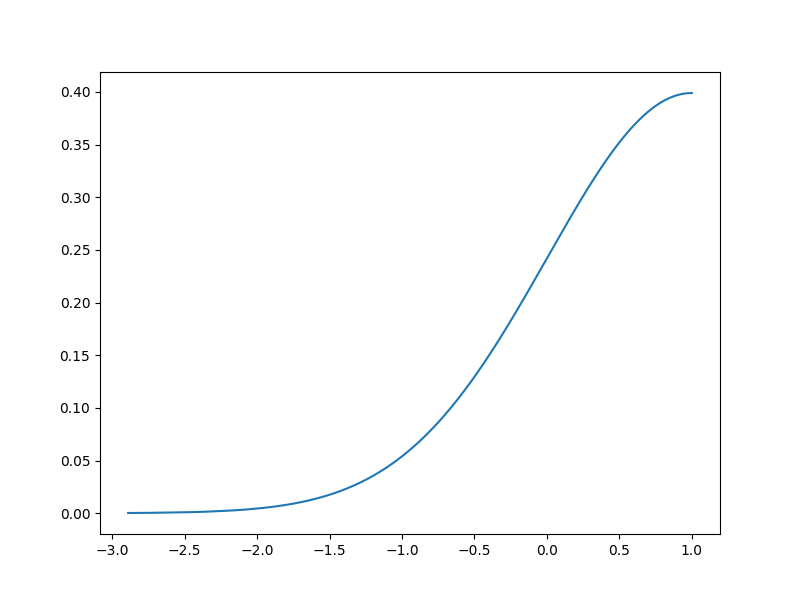

In [242]:
from torch.distributions import MultivariateNormal

def phi(x):
#     return x < 1.0
#     return ch.ones_like(x)
    return x < 1
#     return (x < 1.0) * (x > -1.5)
#     return X[X < 2 & X > -2]

D = 1
num_samples = 10000
M = MultivariateNormal(ch.ones(D), ch.eye(D))

S, alpha, X = generate_data(phi, num_samples, M, D, verbose=True)

sorted_S = S.sort(dim=0)[0]
pdf = ch.exp(M.log_prob(sorted_S))

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(sorted_S, pdf)
plt.show()

In [243]:
emp_loc, emp_var = S.mean(0), S.var(0, keepdim=True)
print(f'emp loc: {emp_loc.item():.3f}')
print(f'emp var: {emp_var.item():.3f}')

std_S = (S - emp_loc)
std_normal = MultivariateNormal(ch.zeros(D), ch.eye(D))
std_loc_S, std_var_S = std_S.mean(0), std_S.var(0, keepdim=True)


pdf = ch.exp(std_normal.log_prob(std_S))[...,None]
loc_grad =  std_loc_S - std_S
cov_grad = .5 * (ch.bmm(std_S.unsqueeze(2), std_S.unsqueeze(1)) - ch.eye(1) - std_loc_S[...,None] @ std_loc_S[None,...]).flatten(1)
data = ch.cat([std_S, pdf, loc_grad, cov_grad], dim=1)

k = 5
unknown_gaussian_oracle = UnknownGaussian(std_loc_S[...,None], ch.eye(1), std_S, k)

emp loc: 0.200
emp var: 0.366


<IPython.core.display.Javascript object>


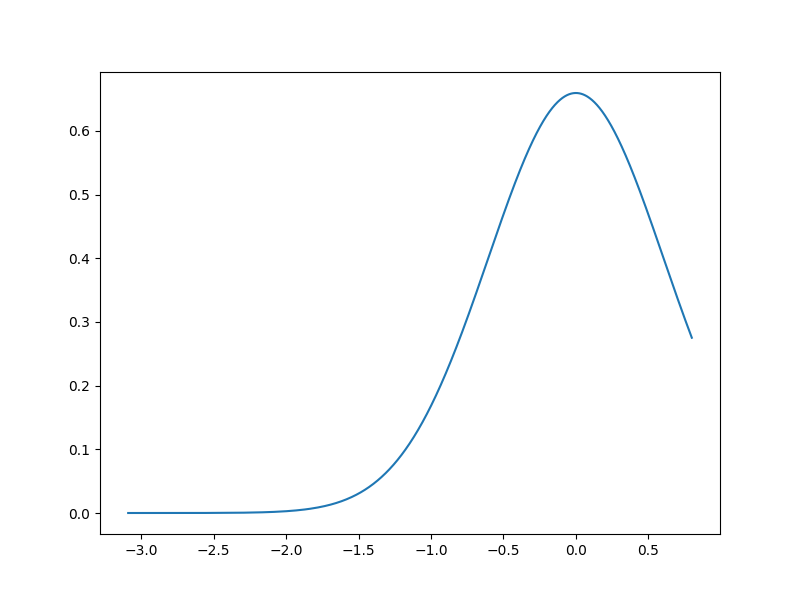

In [244]:
M = MultivariateNormal(std_loc_S, std_var_S)
sorted_S_ = std_S.sort(dim=0)[0]
pdf = ch.exp(M.log_prob(sorted_S_))

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(sorted_S_, pdf)
plt.show()

<IPython.core.display.Javascript object>


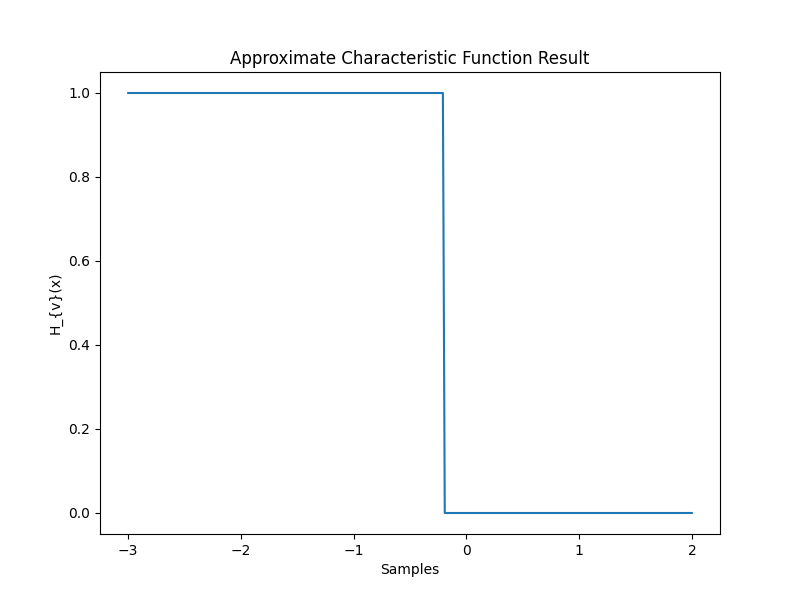

In [245]:
a, b = -2, 3

rand = ((b - a)*ch.rand(1000) - b)[...,None]

rand_sorted = rand.sort(dim=0)[0]

psi_k_results = unknown_gaussian_oracle.psi_k(rand_sorted)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(rand_sorted, psi_k_results)
ax.set_xlabel('Samples')
ax.set_ylabel('H_{v}(x)')
ax.set_title('Approximate Characteristic Function Result')
plt.show()

# Vary MU and Observe Loss Function Convexity 

In [246]:
mus = ch.linspace(-2, 2, 100) 

# exp_h = Exp_h(std_loc_S, ch.eye(1))
exp_h = Exp_h()


losses, mu_grads = ch.Tensor([]), ch.Tensor([])

for mu in mus: 
    loss, cov_grad, loc_grad = unknown_trunc_nll(unknown_gaussian_oracle, exp_h, mu[...,None], ch.eye(1), data)
    losses = ch.cat([losses, loss])
    mu_grads = ch.cat([mu_grads, loc_grad])
    
losses = losses.detach()

<IPython.core.display.Javascript object>


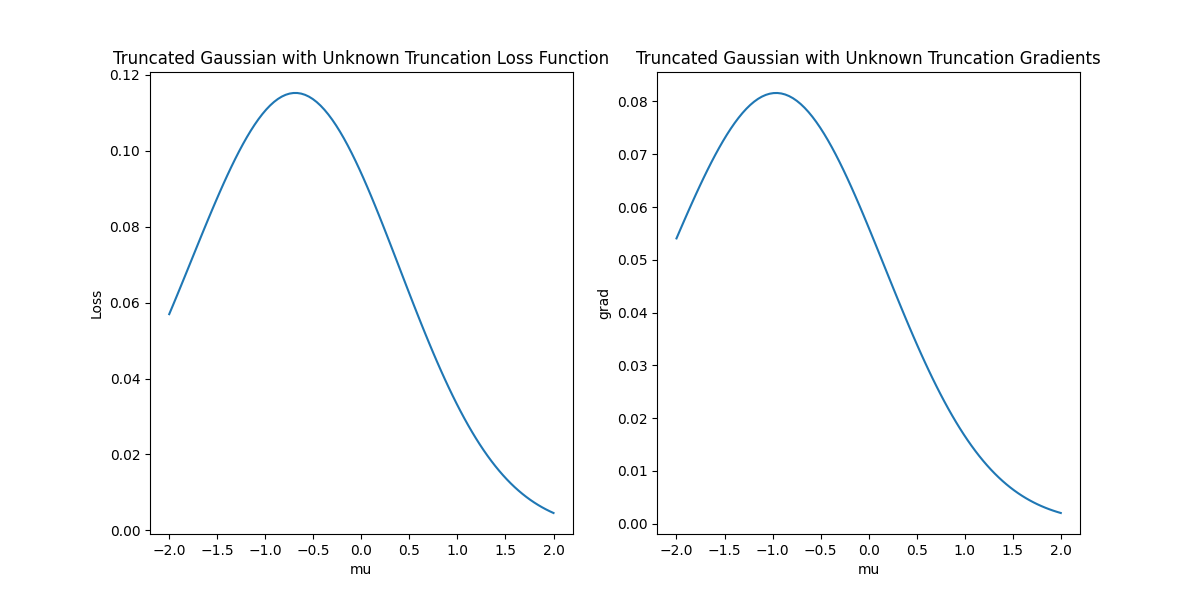

In [247]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.plot(mus, losses)
ax1.set_title('Truncated Gaussian with Unknown Truncation Loss Function')
ax1.set_xlabel('mu')
ax1.set_ylabel('Loss')
ax2.set_title('Truncated Gaussian with Unknown Truncation Gradients')
ax2.plot(mus, mu_grads)
ax2.set_xlabel('mu')
ax2.set_ylabel('grad')

plt.show()

In [235]:
data[:,3:]

tensor([[-0.4914],
        [ 0.0320],
        [-0.4594],
        ...,
        [-0.4891],
        [-0.3388],
        [-0.4910]])

In [211]:
def phi(x):
#     return x < 1.0
#     return ch.ones_like(x)
    return x < 0
#     return (x < 1.0) * (x > -1.5)
#     return X[X < 2 & X > -2]

D = 1
num_samples = 10000
M = MultivariateNormal(ch.zeros(D), ch.eye(D))

S, alpha, X = generate_data(phi, num_samples, M, D, verbose=True)

sorted_S = S.sort(dim=0)[0]
pdf = ch.exp(M.log_prob(sorted_S))

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(sorted_S, pdf)
plt.show()

emp_loc, emp_var = S.mean(0), S.var(0, keepdim=True)
print(f'emp loc: {emp_loc.item():.3f}')
print(f'emp var: {emp_var.item():.3f}')

std_S = (S - emp_loc)
std_normal = MultivariateNormal(ch.zeros(D), ch.eye(D))
std_loc_S, std_var_S = std_S.mean(0), std_S.var(0, keepdim=True)


pdf = ch.exp(std_normal.log_prob(std_S))[...,None]
loc_grad =  std_loc_S - std_S
cov_grad = .5 * (ch.bmm(std_S.unsqueeze(2), std_S.unsqueeze(1)) - ch.eye(1) - std_loc_S[...,None] @ std_loc_S[None,...]).flatten(1)
data = ch.cat([std_S, pdf, loc_grad, cov_grad], dim=1)

k = 5
unknown_gaussian_oracle = UnknownGaussian(std_loc_S[...,None], ch.eye(1), std_S, k)

mus = ch.linspace(-2, 2, 100) 

exp_h = Exp_h(std_loc_S, ch.eye(1))

losses, mu_grads = ch.Tensor([]), ch.Tensor([])

for mu in mus: 
    loss, cov_grad, loc_grad = unknown_trunc_nll(unknown_gaussian_oracle, exp_h, mu[...,None], ch.eye(1), data)
    losses = ch.cat([losses, loss])
    mu_grads = ch.cat([mu_grads, loc_grad])
    
losses = losses.detach()



tensor([[3.8654e-33]])

In [212]:
std_S.var(0)

tensor([0.3571])

In [210]:
.5 * (ch.bmm(std_S.unsqueeze(2), std_S.unsqueeze(1)) - ch.eye(1) - std_loc_S[...,None] @ std_loc_S[None,...]).flatten(1)



tensor([[ 0.1335],
        [-0.4133],
        [ 0.1340],
        ...,
        [ 0.5085],
        [ 0.0131],
        [-0.2102]])

In [248]:
mus[losses.argmax()] + emp_loc

tensor([-0.5070])

In [241]:
emp_loc

tensor([-0.8052])

In [220]:
mus[ch.abs(mu_grads).argmin()] + emp_loc

tensor([-0.7707])

In [179]:
loss_argmin = losses.argmin()
print(f'loss: {losses[loss_argmin]}')
print(f'min mu: {mus[loss_argmin] + emp_loc}')

loss: tensor([1.0002])
min mu: tensor([1.0023])


In [22]:
loss, cov_grad, loc_grad = unknown_trunc_nll(unknown_gaussian_oracle, exp_h, ch.zeros(1,), ch.eye(1), data)
print(f'loss: {loss}')

loss: tensor([[1.1582]], grad_fn=<SumBackward1>)


In [140]:
norm = Normal(ch.zeros(1), ch.eye(1))

In [173]:
# helpers: exp_h(u,B,x) must return shape (n,)
def Mf_on_grid(mu_grid, B_fixed, psi_fn, mc_per_mu=20000):
    Mf_vals = []
    for mu in mu_grid:
        x_mc = mu + sigma * ch.randn(mc_per_mu, 1)
        with ch.no_grad():
            expvals = exp_h(ch.tensor([mu]), B_fixed, x_mc)
            psi_vals = psi_fn(x_mc)
#             pdf = ch.exp(norm.log_prob(x_mc))
            mf_val = float((expvals * psi_vals).mean().item())
#             print(f'pdf: {pdf.mean(0)}')
#             print(f'mf val: {mf_val}')
        Mf_vals.append(mf_val)
    return ch.tensor(Mf_vals)

# psi functions:
def psi_true(x):
    return (x < 1.0).float()

def psi_learned(x):
    return unknown_gaussian_oracle.psi_k(x).squeeze()

# Choose B_fixed as the B you use in experiments. If you keep B fixed=I, use that.
B_fixed = ch.eye(1)

Mf_true = Mf_on_grid(mus, B_fixed, psi_true)
Mf_learned = Mf_on_grid(mus, B_fixed, psi_learned)

# Print minima positions
min_true_mu = float(mus[Mf_true.argmin()].item())
min_learned_mu = float(mus[Mf_learned.argmin()].item())
print('minima (true indicator):', min_true_mu)
print('minima (learned psi):', min_learned_mu)

minima (true indicator): 1.5151515151515151
minima (learned psi): 1.3535353535353534


In [174]:
import torch
std = 1.0
base = Normal(ch.tensor(0.0), ch.tensor(std))
def Mf_on_grid_importance(mu_grid, B_fixed, psi_fn, mc_per_mu=200000, device='cpu'):
    Mf_vals = []
    for mu in mu_grid:
        q = Normal(ch.tensor(mu, device=device), torch.tensor(std, device=device))
        x_mc = q.sample((mc_per_mu, 1))  # samples from N(mu,1)
        with torch.no_grad():
            expvals = exp_h(ch.tensor([mu], device=device), B_fixed, x_mc).squeeze()
            psi_vals = psi_fn(x_mc).squeeze()
            # compute log weights = log phi_0(x) - log q(x)
            logw = base.log_prob(x_mc).squeeze() - q.log_prob(x_mc).squeeze()
            # stable weighted average: mean( exp(logw) * expvals * psi )
            # compute in log space to avoid overflow
            integrand = torch.log(torch.clamp(expvals, min=1e-300)) + torch.log(torch.clamp(psi_vals, min=1e-300)) + logw
            # use log-sum-exp to compute mean(exp(integrand))
            maxv = integrand.max()
            mean_exp = torch.exp(integrand - maxv).mean()
            Mf_val = float((maxv.exp() * mean_exp).item())
        Mf_vals.append(Mf_val)
    return torch.tensor(Mf_vals)

# Choose B_fixed as the B you use in experiments. If you keep B fixed=I, use that.
B_fixed = ch.eye(1)

Mf_true = Mf_on_grid_importance(mus, B_fixed, psi_true)
Mf_learned = Mf_on_grid_importance(mus, B_fixed, psi_learned)

# Print minima positions
min_true_mu = float(mus[Mf_true.argmin()].item())
min_learned_mu = float(mus[Mf_learned.argmin()].item())
print('minima (true indicator):', min_true_mu)
print('minima (learned psi):', min_learned_mu)


/tmp/ipykernel_257430/4105310003.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  q = Normal(ch.tensor(mu, device=device), torch.tensor(std, device=device))


minima (true indicator): -1.0303030303030303
minima (learned psi): -0.9494949494949494


In [167]:
norm_ = Normal(ch.zeros(1,), ch.eye(1))
samples = norm_.sample([250000]).squeeze(-1)

ch.exp(norm_.log_prob(samples)).max()

tensor(0.3989)

# Vary Sigma and Observe Loss Function Convexity

In [16]:
sigmas = ch.linspace(.75, 2, 100) 

exp_h = Exp_h(emp_loc, emp_var)

losses, cov_grads = ch.Tensor([]), ch.Tensor([])

for sigma in sigmas: 
    var_ = ch.Tensor([[sigma]])
    loss, cov_grad, loc_grad = unknown_trunc_nll(unknown_gaussian_oracle, exp_h, ch.zeros(1,), var_, data)
    losses = ch.cat([losses, loss])
    cov_grads = ch.cat([cov_grads, cov_grad])
    
losses = losses.detach()

<IPython.core.display.Javascript object>


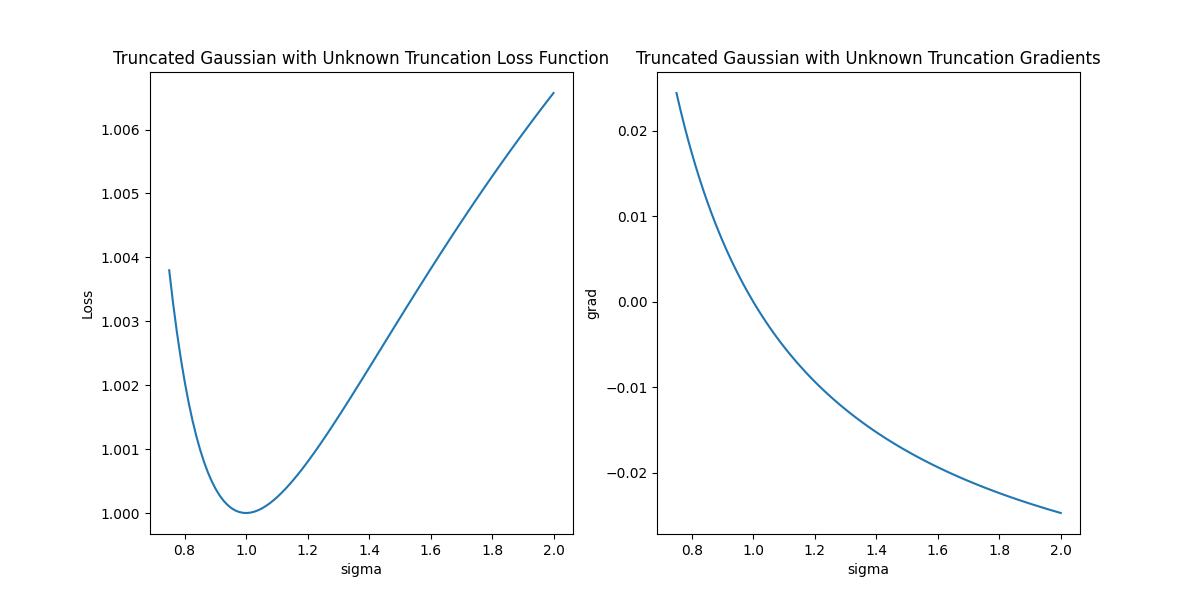

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.plot(sigmas, losses)
ax1.set_title('Truncated Gaussian with Unknown Truncation Loss Function')
ax1.set_xlabel('sigma')
ax1.set_ylabel('Loss')
ax2.set_title('Truncated Gaussian with Unknown Truncation Gradients')
ax2.plot(sigmas, cov_grads)
ax2.set_xlabel('sigma')
ax2.set_ylabel('grad')

plt.show()

In [74]:
grid = ch.linspace(-4, 4, 1001).view(-1,1)
psi_grid = unknown_gaussian_oracle.psi_k(grid).squeeze().detach().cpu().numpy()   # should be in [0,1]
# find first grid point where psi>0.5
idx = (psi_grid > 0.5).argmax()
print('decision boundary approx (raw x):', grid[idx].item())

decision boundary approx (raw x): -4.0


In [99]:
# compute raw expansion (no sigmoid/clamp)
H_grid = unknown_gaussian_oracle.H_v(grid)               # uses standardization inside
expansion = (H_grid * unknown_gaussian_oracle._C_v.view(1,-1)).sum(dim=1).detach().cpu().numpy()
# find x where expansion≈0 (interpolate)
import numpy as np
zero_idx = np.argmin(np.abs(expansion))
print('expansion min-abs at x=', grid[zero_idx].item(), 'expansion value=', expansion[zero_idx])

expansion min-abs at x= 1.64 expansion value= -0.0017216437067582024


In [100]:
emp_loc = unknown_gaussian_oracle.emp_loc.item()
emp_var = unknown_gaussian_oracle.emp_covariance_matrix.reshape(-1)[0].item()
std = emp_var**0.5
print('emp_loc,std', emp_loc, std)
print('z for x=0:', (0-emp_loc)/std, 'z for x=1:', (1-emp_loc)/std)

emp_loc,std -0.15011646354651975 0.6416664814906582
z for x=0: 0.2339478029112313 z for x=1: 1.7923898110973153


In [101]:
import torch as ch
import numpy as np

# grid in raw x
grid = ch.linspace(-2.0, 2.0, 2001).view(-1,1)   # adjust range if needed

# raw expansion (before sigmoid/clamp)
H_grid = unknown_gaussian_oracle.H_v(grid)                        # standardizes internally
expansion_grid = (H_grid * unknown_gaussian_oracle._C_v.view(1,-1)).sum(dim=1).detach().cpu().numpy()

# psi after your postprocessing (sigmoid/clamp) - replace call if needed
psi_grid = unknown_gaussian_oracle.psi_k(grid).squeeze().detach().cpu().numpy()  # should be in [0,1]

# ratio (if you use it in __call__)
# ensure oracle._dist is set; otherwise skip ratio
try:
    ratio_grid = ch.exp(oracle.emp_dist.log_prob(grid) - unknown_gaussian_oracle.dist.log_prob(grid)).squeeze().detach().cpu().numpy()
except Exception as e:
    ratio_grid = None

# product used in thresholding (if you do ratio*psi)
prod_grid = None
if ratio_grid is not None:
    prod_grid = ratio_grid * psi_grid

# find zero-crossings / boundaries
def first_above(arr, val=0.5):
    idx = np.where(arr > val)[0]
    return None if len(idx)==0 else float(grid[idx[0]].item())

print('expansion zero-cross approx at x where abs(expansion) minimal:')
idx = np.argmin(np.abs(expansion_grid))
print('  x=', float(grid[idx].item()), 'expansion=', float(expansion_grid[idx]))

print('psi 0.5 boundary approx:', first_above(psi_grid, 0.5))
if ratio_grid is not None:
    print('ratio  stats: min,mean,max =', ratio_grid.min(), ratio_grid.mean(), ratio_grid.max())
    print('prod (ratio*psi) 0.5 boundary approx:', first_above(prod_grid, 0.5))
else:
    print('ratio not available (oracle.dist not set)')

# optional: show expansion at x=0 and x=0.504
for x in [0.0, 0.504]:
    xi = ch.tensor([[x]], dtype=grid.dtype, device=grid.device)
    print(f'expansion @ {x}:', float(((unknown_gaussian_oracle.H_v(xi) * unknown_gaussian_oracle._C_v.view(1,-1)).sum(dim=1)).item()),
          'psi @', x, float(unknown_gaussian_oracle.psi_k(xi).item()))

expansion zero-cross approx at x where abs(expansion) minimal:
  x= 1.64 expansion= -0.0017216437067582024
psi 0.5 boundary approx: -2.0
ratio not available (oracle.dist not set)
expansion @ 0.0: 0.9326894967430851 psi @ 0.0 0.9999110097692955
expansion @ 0.504: 1.162633976757825 psi @ 0.504 0.999991072272684


In [102]:
psi_vals = unknown_gaussian_oracle.psi_k(X).squeeze().detach().cpu().numpy()
indicator = (X.squeeze().numpy() > 0).astype(float)   # if A = {x>0}
import sklearn.metrics as skm
auc = skm.roc_auc_score(indicator, psi_vals)
print('AUC', auc)

AUC 0.5900649805848253


In [103]:
expansion = (unknown_gaussian_oracle._C_v * unknown_gaussian_oracle.H_v(X)).sum(dim=1)
print(expansion.mean().item(), expansion.std().item(), expansion.min().item(), expansion.max().item())

0.7706442992931316 1.3996197486448823 -76.24848245016317 1.340124289299878


alpha: 0.505
Ground truth: μ=0.000, σ=1.000
Minimum found: μ=-0.103, σ=1.069, loss=1.000

Loss at ground truth: 1.000
Loss at minimum: 1.000
Difference: -0.000


<IPython.core.display.Javascript object>


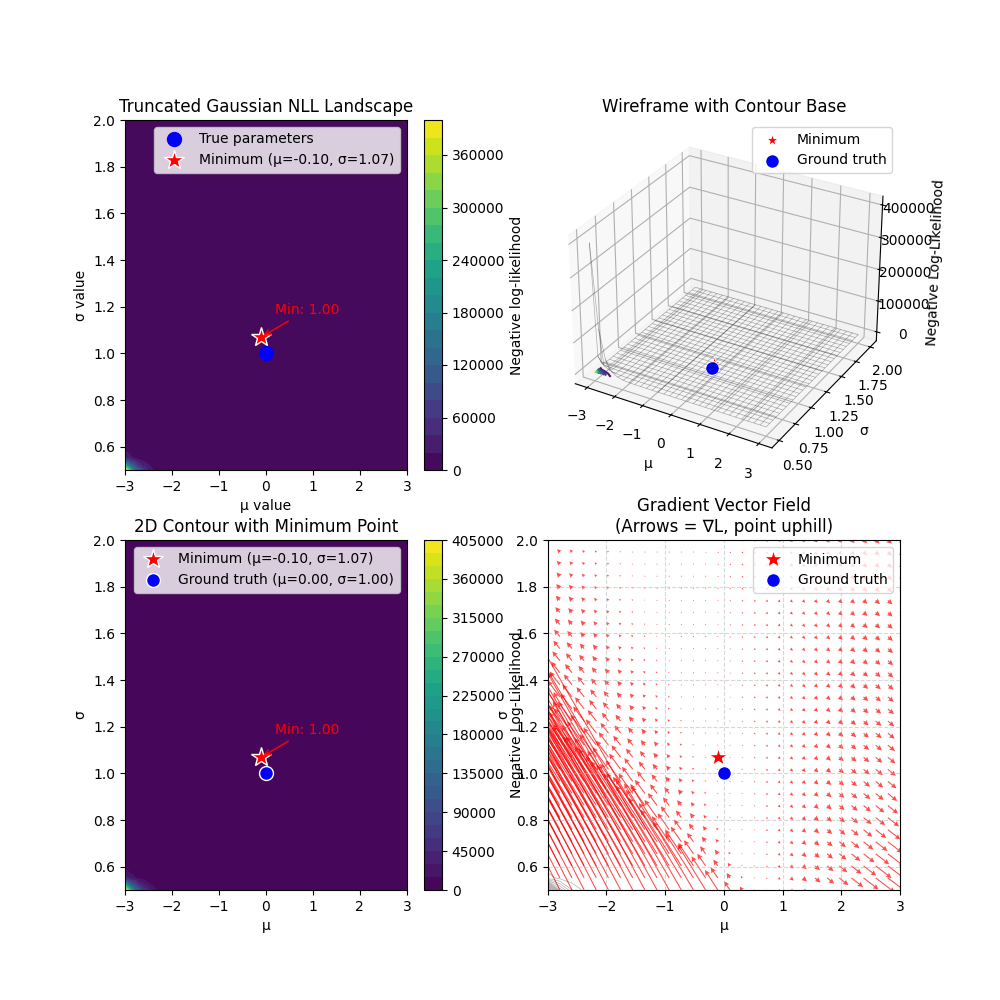

In [104]:
D = 1
num_samples = 10000
true_mu = ch.zeros(D)
true_var = ch.eye(D)
M = MultivariateNormal(true_mu, true_var)

def phi(x): return x > 0

S, alpha, X = generate_data(phi, num_samples, M, D, verbose=True)

k = 5
emp_loc, emp_var = S.mean(0), S.var(0, keepdim=True)
unknown_gaussian_oracle = UnknownGaussian(emp_loc[...,None], emp_var, S, k)
exp_h = Exp_h(emp_loc, emp_var)

# === Parameter grids ===
mu_values = ch.linspace(-3.0, 3.0, 30)
sigma_values = ch.linspace(0.5, 2.0, 30)
MU, SIGMA = ch.meshgrid(mu_values, sigma_values)

pdf = ch.exp(std_normal.log_prob(S))[...,None]
loc_grad =  emp_loc - S
cov_grad = .5 * (ch.bmm(S.unsqueeze(2), S.unsqueeze(1)) - emp_var - emp_loc[...,None] @ emp_loc[None,...]).flatten(1)
data = ch.cat([S, pdf, loc_grad, cov_grad], dim=1) 

# === Compute NLL over the grid ===
Z = np.zeros_like(MU)
MU_GRAD = np.zeros_like(MU)
SIGMA_GRAD = ch.zeros_like(SIGMA) 
for i in range(len(sigma_values)):
    for j in range(len(mu_values)):
        var = ch.Tensor([[SIGMA[i, j]]])
        loss, cov_grad, loc_grad = unknown_trunc_nll(unknown_gaussian_oracle, exp_h, MU[i, j][...,None], var, data)
        Z[i, j] = loss
        MU_GRAD[i, j] = loc_grad.flatten()
        SIGMA_GRAD[i, j] = cov_grad.flatten()
        
min_idx = np.unravel_index(np.argmin(Z), Z.shape)
min_mu = MU[min_idx]
min_sigma = SIGMA[min_idx]
min_loss = Z[min_idx]
print(f"Ground truth: μ={true_mu.item():.3f}, σ={true_var.sqrt().item():.3f}")
print(f"Minimum found: μ={min_mu:.3f}, σ={min_sigma:.3f}, loss={min_loss:.3f}")
gt_loss = unknown_trunc_nll(unknown_gaussian_oracle, exp_h, true_mu, true_var, data)[0].item()
print(f"\nLoss at ground truth: {gt_loss:.3f}")
print(f"Loss at minimum: {min_loss:.3f}")
print(f"Difference: {gt_loss - min_loss:.3f}")

# === Plot the loss landscape ===
fig = plt.figure(figsize=(10, 10))

ax1 = fig.add_subplot(221,)
cp = ax1.contourf(MU, SIGMA, Z, levels=20, cmap="viridis")
plt.colorbar(cp, ax=ax1, label="Negative log-likelihood")

ax1.set_title("Truncated Gaussian NLL Landscape")
ax1.set_xlabel("μ value")
ax1.set_ylabel("σ value")

# mark the ground truth
ax1.plot(true_mu.item(), true_var.sqrt().item(), 'bo', markersize=10, label="True parameters")

ax1.plot(min_mu, min_sigma, 'r*', markersize=15, markeredgecolor='white', 
        label=f'Minimum (μ={min_mu:.2f}, σ={min_sigma:.2f})')

ax1.annotate(f'Min: {min_loss:.2f}', 
            xy=(min_mu, min_sigma), 
            xytext=(min_mu+0.3, min_sigma+0.1),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')

ax1.legend()

# Plot 2: 3D wireframe plot
ax2 = fig.add_subplot(222, projection='3d')
ax2.plot_wireframe(MU, SIGMA, Z, color='black', alpha=0.3, linewidth=0.5)
contour = ax2.contour(MU, SIGMA, Z, levels=15, offset=np.min(Z) - 0.1, cmap='viridis')
ax2.scatter([min_mu], [min_sigma], [min_loss], color='red', s=100, 
           label='Minimum', marker='*', edgecolors='white')
ax2.scatter([true_mu.item()], [true_var.sqrt().item()], [np.min(Z)], 
           color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')
ax2.set_xlabel('μ')
ax2.set_ylabel('σ')
ax2.set_zlabel('Negative Log-Likelihood')
ax2.set_title('Wireframe with Contour Base')
ax2.legend()

# Plot 3: Heatmap with minimum point
ax3 = fig.add_subplot(223)
contourf = ax3.contourf(MU, SIGMA, Z, levels=30, cmap='viridis')
plt.colorbar(contourf, ax=ax3, label='Negative Log-Likelihood')

# Mark minimum and ground truth
ax3.plot(min_mu, min_sigma, 'r*', markersize=15, markeredgecolor='white', 
        label=f'Minimum (μ={min_mu:.2f}, σ={min_sigma:.2f})')
ax3.plot(true_mu.item(), true_var.sqrt().item(), 'bo', markersize=10, 
        markeredgecolor='white', label=f'Ground truth (μ={true_mu.item():.2f}, σ={true_var.sqrt().item():.2f})')

# Add text annotation for the minimum point
ax3.annotate(f'Min: {min_loss:.2f}', 
            xy=(min_mu, min_sigma), 
            xytext=(min_mu+0.3, min_sigma+0.1),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')

ax3.set_xlabel('μ')
ax3.set_ylabel('σ')
ax3.set_title('2D Contour with Minimum Point')
ax3.legend()

# Plot 4: Gradient
ax4 = fig.add_subplot(224)

# Plot quiver
Q = ax4.quiver(MU, SIGMA, MU_GRAD, SIGMA_GRAD,
               color='red', alpha=0.7, width=0.003, scale=50, headwidth=5)

# Add contour of loss for context
contour = ax4.contour(MU, SIGMA, Z, levels=15, colors='black', alpha=0.3, linewidths=0.5)
ax4.clabel(contour, inline=True, fontsize=8, fmt="%.1f")

# Mark minimum and ground truth
ax4.plot(min_mu, min_sigma, 'r*', markersize=15, markeredgecolor='white', label='Minimum')
ax4.plot(true_mu.item(), true_var.sqrt().item(), 'bo', markersize=10, markeredgecolor='white', label='Ground truth')

ax4.set_xlabel('μ')
ax4.set_ylabel('σ')
ax4.set_title('Gradient Vector Field\n(Arrows = ∇L, point uphill)')
ax4.legend()
ax4.grid(True, linestyle='--', alpha=0.5)


plt.show()

# Two Dimensional Gaussian

In [106]:
# === Ground truth parameters ===
D = 2
true_mu = ch.zeros(D)
true_var = ch.eye(D)
true_T = ch.inverse(true_var)
true_v = true_T @ true_mu

print(f'true mean: {true_mu.tolist()}')
print(f'true covariance: {true_var.tolist()}')

true mean: [0.0, 0.0]
true covariance: [[1.0, 0.0], [0.0, 1.0]]


alpha: 0.247


<IPython.core.display.Javascript object>


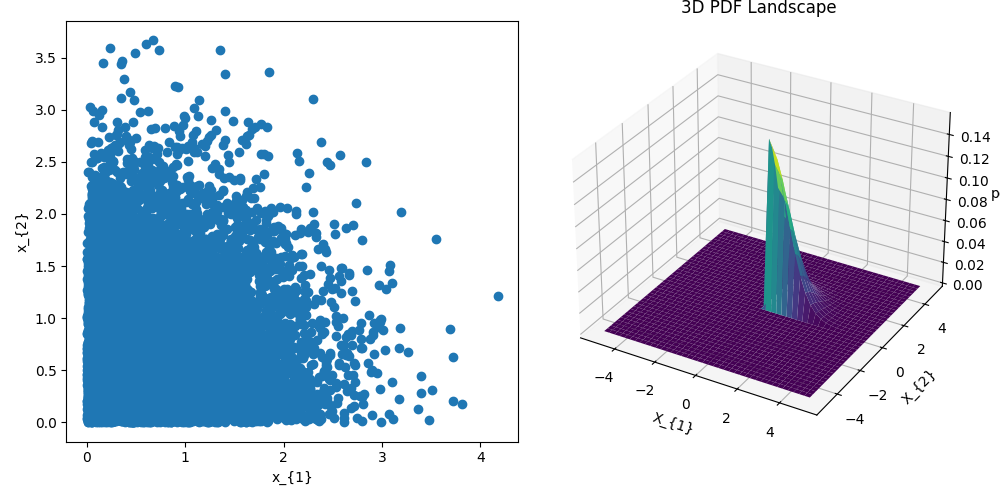

In [107]:
M = MultivariateNormal(ch.zeros(D), ch.eye(D))
SAMPLES = M.sample([1000])

# === Synthetic truncated dataset ===
M = MultivariateNormal(true_mu, true_var)

# === Truncation region ===
def phi(z):
    # Keep only samples where both coordinates > 0
    return (z > 0).prod(dim=-1, keepdim=True)
S, alpha, samples = generate_data(phi, num_samples, M, D, verbose=True)

fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(121)
ax1.scatter(S[:,0], S[:,1])
ax1.set_xlabel('x_{1}')
ax1.set_ylabel('x_{2}')

x_ = ch.linspace(-5.0, 5.0, 40)
y_ = ch.linspace(-5.0, 5.0, 40)
X, Y = ch.meshgrid(x_, y_)

coords = ch.stack([X, Y], dim=-1)
coords_flat = coords.reshape(-1, 2)

pdfs = ch.exp(M.log_prob(coords_flat))[...,None]
mask = phi(coords_flat)

truncated_pdfs = (pdfs * mask).reshape(X.shape)   
        
ax2 = fig.add_subplot(122, projection='3d')

ax2.plot_surface(X, Y, truncated_pdfs,cmap='viridis',linewidth=0)
ax2.set_xlabel('X_{1}')
ax2.set_ylabel('X_{2}')
ax2.set_zlabel('pdf')
ax2.set_title('3D PDF Landscape')

plt.tight_layout()
plt.show()

In [108]:
k = 5
emp_loc, cov_ = S.mean(0), ch.eye(D)
unknown_gaussian_oracle = UnknownGaussian(emp_loc, cov_, S, k)

pdf = ch.exp(M.log_prob(S))[...,None]
loc_grad =  emp_loc - S
cov_grad = .5 * (ch.bmm(S.unsqueeze(2), S.unsqueeze(1)) - emp_var - emp_loc[...,None] @ emp_loc[None,...]).flatten(1)
data = ch.cat([S, pdf, loc_grad, cov_grad], dim=1) 

<>:21: SyntaxWarning: invalid escape sequence '\i'
<>:21: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_233477/3405096069.py:21: SyntaxWarning: invalid escape sequence '\i'
  ax2.set_zlabel('x \in S')


<IPython.core.display.Javascript object>


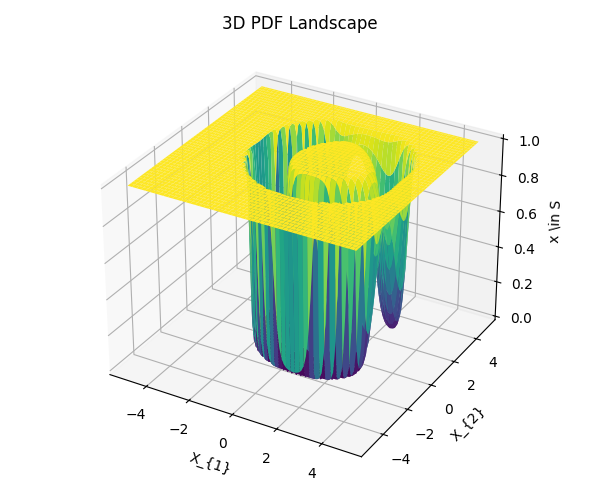

In [109]:
x_, y_ = ch.linspace(-5, 5, 100), ch.linspace(-5, 5, 100)
x_mesh, y_mesh = ch.meshgrid(x_, y_)

psi_ = ch.zeros_like(x_mesh)
for i in range(len(x_mesh)): 
    for j in range(len(y_mesh)): 
        s = ch.cat([x_mesh[i, j][...,None], y_mesh[i, j][...,None]])[None,...]
        psi_k = unknown_gaussian_oracle.psi_k(s)
        psi_[i, j] = psi_k
        


fig = plt.figure(figsize=(6, 5))


ax2 = fig.add_subplot(111, projection='3d')

ax2.plot_surface(x_mesh, y_mesh, psi_, cmap='viridis',linewidth=0)
ax2.set_xlabel('X_{1}')
ax2.set_ylabel('X_{2}')
ax2.set_zlabel('x \in S')
ax2.set_title('3D PDF Landscape')

plt.tight_layout()
plt.show()

<IPython.core.display.Javascript object>


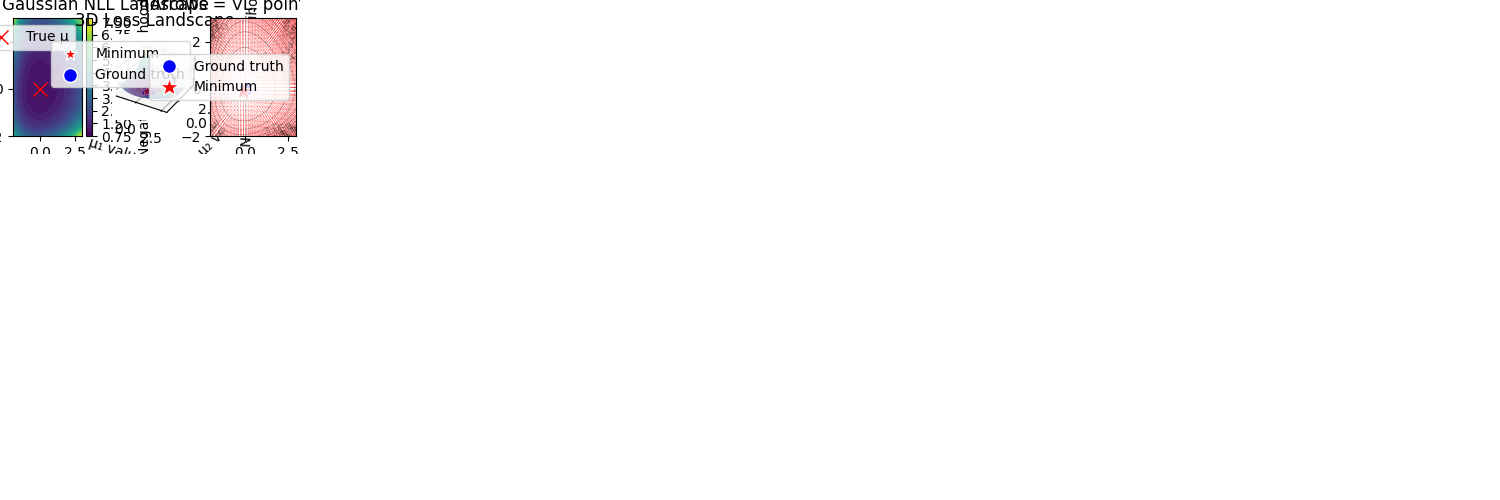


Loss at ground truth: 0.993
Loss at minimum: 0.994
Difference: -0.001


In [110]:
exp_h = Exp_h(emp_loc, ch.eye(D))

# === Parameter grid for μ₁ and μ₂ ===
mu1_vals = ch.linspace(-2.0, 3.0, 40)
mu2_vals = ch.linspace(-2.0, 3.0, 40)
MU1, MU2 = ch.meshgrid(mu1_vals, mu2_vals)

Z = np.zeros_like(MU1)
MU1_GRAD = ch.zeros_like(MU1)
MU2_GRAD = ch.zeros_like(MU2)
for i in range(len(mu2_vals)):
    for j in range(len(mu1_vals)):
        mu_vec = ch.Tensor([MU1[i, j], MU2[i, j]])
        loss, cov_grad, loc_grad = unknown_trunc_nll(unknown_gaussian_oracle, exp_h, mu_vec, cov_, data, dims=D)
        Z[i, j] = loss
        MU1_GRAD[i, j] = loc_grad[0]
        MU2_GRAD[i, j] = loc_grad[1]
        
min_idx = np.unravel_index(np.argmin(Z), Z.shape)
min_mu_1, min_mu_2 = MU1[min_idx], MU2[min_idx]
min_loss = Z[min_idx]

fig = plt.figure(figsize=(15, 5))

# === 2D contour plot ===
ax1 = fig.add_subplot(131)
cp = ax1.contourf(MU1, MU2, Z, levels=30, cmap="viridis")
plt.colorbar(cp, ax=ax1, label="Negative log-likelihood")

ax1.set_title("2D Truncated Gaussian NLL Landscape")
ax1.set_xlabel("μ₁ value")
ax1.set_ylabel("μ₂ value")

# mark the ground truth
ax1.plot(true_mu[0].item(), true_mu[1].item(), 'rx', markersize=10, label="True μ")
ax1.legend()

# === 3D surface plot ===
ax2 = fig.add_subplot(132, projection='3d')
surf = ax2.plot_surface(MU1, MU2, Z, cmap='viridis', alpha=0.85,
                        linewidth=0, antialiased=True)

# plot key points
ax2.scatter([min_mu_1], [min_mu_2], [min_loss],
            color='red', s=100, label='Minimum', marker='*', edgecolors='white')
ax2.scatter([true_mu[0].item()], [true_mu[1].item()], [np.min(Z)],
            color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')

# formatting
ax2.set_xlabel('μ₁ value')
ax2.set_ylabel('μ₂ value')
ax2.set_zlabel('Negative Log-Likelihood')
ax2.set_title('3D Loss Landscape')
ax2.legend()

# fix clipping
ax2.set_box_aspect((1, 1, 0.6))  # prevents z from being squashed
ax2.set_xlim(MU1.min(), MU1.max())
ax2.set_ylim(MU2.min(), MU2.max())
ax2.set_zlim(Z.min() - 0.1 * abs(Z.min()), Z.max() + 0.1 * abs(Z.max()))

# Plot 3: Gradient
ax3 = fig.add_subplot(133)

# Plot quiver
Q = ax3.quiver(MU1, MU2, MU1_GRAD, MU2_GRAD,
               color='red', alpha=0.7, width=0.003, scale=5, headwidth=5)

# Add contour of loss for context
contour = ax3.contour(MU1, MU2, Z, levels=15, colors='black', alpha=0.3, linewidths=0.5)
ax3.clabel(contour, inline=True, fontsize=8, fmt="%.1f")

# Mark minimum and ground truth
ax3.plot(true_mu[0].item(), true_mu[1].item(), 'bo', markersize=10, markeredgecolor='white', label='Ground truth')
ax3.plot(min_mu_1, min_mu_2, 'r*', markersize=15, markeredgecolor='white', label='Minimum')

ax3.set_xlabel('μ_1')
ax3.set_ylabel('μ_2')
ax3.set_title('Gradient Vector Field\n(Arrows = ∇L, point uphill)')
ax3.legend()
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# === Additional analysis ===
loss = unknown_trunc_nll(unknown_gaussian_oracle, exp_h, ch.zeros(D,), cov_, data, dims=D)[0].item()
print(f"\nLoss at ground truth: {loss:.3f}")
print(f"Loss at minimum: {min_loss:.3f}")
print(f"Difference: {loss - min_loss:.3f}")

# Vary mu_1 and sigma_1

/tmp/ipykernel_233477/3720593500.py:28: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  min_idx = np.unravel_index(np.argmin(Z_mu_sigma), Z_mu_sigma.shape)


<IPython.core.display.Javascript object>


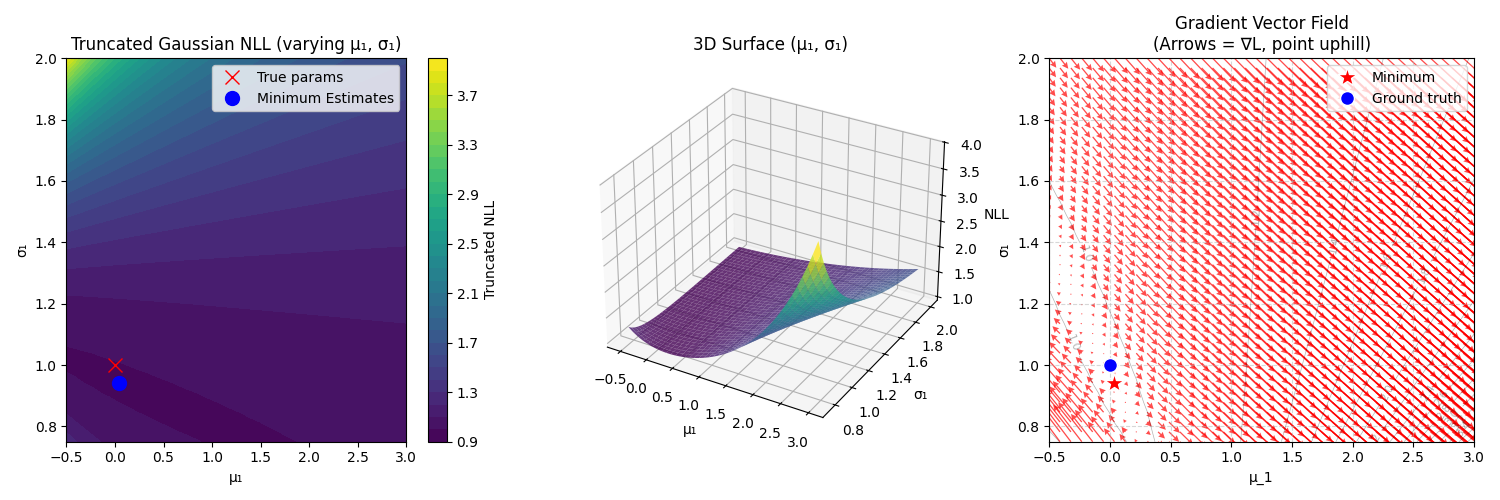


Loss at ground truth: 0.993
Loss at minimum: 0.993
Difference: 0.000


In [37]:
from delphi.utils.helpers import cov
cov_ = cov(S)
exp_h = Exp_h(emp_loc, cov_)


# ==== Vary μ₁ and σ₁ (fix μ₂, σ₂) ====
mu1_vals = ch.linspace(-.5, 3, 40)
sigma1_vals = ch.linspace(0.75, 2.0, 40)
MU1, SIGMA1 = ch.meshgrid(mu1_vals, sigma1_vals)
Z_mu_sigma = ch.zeros_like(MU1)
GRAD_MU1 = ch.zeros_like(MU1)
GRAD_SIGMA1 = ch.zeros_like(SIGMA1)

sigma2_fixed = 1.0

for i in range(len(sigma1_vals)):
    for j in range(len(mu1_vals)):
        mu = ch.tensor([MU1[i, j], true_mu[1]])
        
        Sigma = ch.diag(ch.tensor([SIGMA1[i, j], sigma2_fixed]))
        loss, cov_grad, loc_grad = unknown_trunc_nll(unknown_gaussian_oracle, exp_h, mu, Sigma, data, dims=D)

        Z_mu_sigma[i, j] = loss
        GRAD_MU1[i, j] = loc_grad[0]
        GRAD_SIGMA1[i, j] = cov_grad[0, 0]
        
Z_mu_sigma = Z_mu_sigma.detach()
min_idx = np.unravel_index(np.argmin(Z_mu_sigma), Z_mu_sigma.shape)
min_mu_1, min_sigma_1 = MU1[min_idx], SIGMA1[min_idx]
min_loss = Z_mu_sigma[min_idx]

# ==== Visualization ====
fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(1, 3, 1)
cp = ax1.contourf(mu1_vals, sigma1_vals, Z_mu_sigma, levels=30, cmap="viridis")
plt.colorbar(cp, ax=ax1, label="Truncated NLL")
ax1.plot(true_mu[0], 1.0, "rx", markersize=10, label="True params")
ax1.plot(min_mu_1, min_sigma_1, "bo", markersize=10, label="Minimum Estimates")

ax1.set_title("Truncated Gaussian NLL (varying μ₁, σ₁)")
ax1.set_xlabel("μ₁")
ax1.set_ylabel("σ₁")
ax1.legend()

ax2 = fig.add_subplot(1, 3, 2, projection="3d")
ax2.plot_surface(MU1, SIGMA1, Z_mu_sigma, cmap="viridis", alpha=0.8, linewidth=0)
ax2.set_xlabel("μ₁")
ax2.set_ylabel("σ₁")
ax2.set_zlabel("NLL")
ax2.set_title("3D Surface (μ₁, σ₁)")

# Plot 3: Gradient
ax3 = fig.add_subplot(133)

# Plot quiver
Q = ax3.quiver(MU1, SIGMA1, GRAD_MU1, GRAD_SIGMA1,
               color='red', alpha=0.7, width=0.003, scale=5, headwidth=5)

# Add contour of loss for context
contour = ax3.contour(MU1, SIGMA1, Z_mu_sigma, levels=15, colors='black', alpha=0.3, linewidths=0.5)
ax3.clabel(contour, inline=True, fontsize=8, fmt="%.1f")

# Mark minimum and ground truth
ax3.plot(min_mu_1, min_sigma_1, 'r*', markersize=15, markeredgecolor='white', label='Minimum')
ax3.plot(true_mu[0].item(), 1.0, 'bo', markersize=10, markeredgecolor='white', label='Ground truth')

ax3.set_xlabel('μ_1')
ax3.set_ylabel('σ₁')
ax3.set_title('Gradient Vector Field\n(Arrows = ∇L, point uphill)')
ax3.legend()
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# === Additional analysis ===
loss = unknown_trunc_nll(unknown_gaussian_oracle, exp_h, true_mu, ch.eye(D), data, dims=D)[0].item()
print(f"\nLoss at ground truth: {loss:.3f}")
print(f"Loss at minimum: {min_loss:.3f}")
print(f"Difference: {loss - min_loss:.3f}")

In [39]:
min_sigma_1, min_mu_1

(tensor(0.9423), tensor(0.0385))

# 10 Dimensional Gaussians

In [44]:
D = 10
true_mu = ch.randn(D) 
true_Sigma = 10.0 * ch.eye(D)
dist = MultivariateNormal(true_mu, true_Sigma)

print(f'true mu: {true_mu.tolist()}')
print(f'true Sigma: {true_Sigma.tolist()}')

true mu: [1.2893456795458005, 1.0122873513999349, -0.043579447656541585, 1.0751504662949576, 1.0823997970179047, 0.4196386799946605, -0.5557916198532369, -0.4319157954769031, -1.799735173810274, 0.32434229517987195]
true Sigma: [[10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 10.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 10.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.0]]


# Random Matrix Projection

alpha: 0.998
Effective 2D radius (min): 0.10


<IPython.core.display.Javascript object>


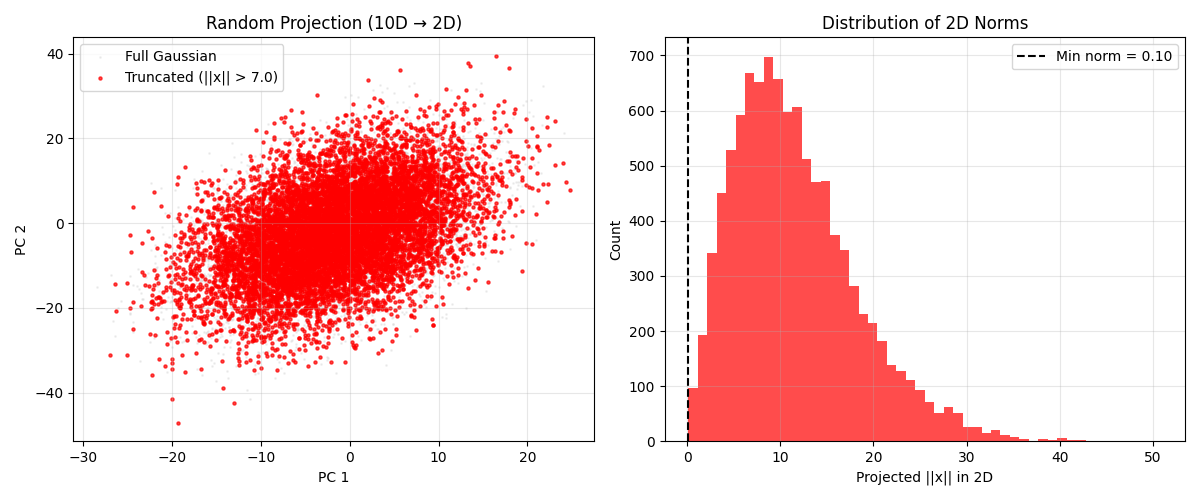

In [53]:
M = MultivariateNormal(true_mu, true_Sigma)
# === Truncation region ===
def phi(z):
    # Keep only samples, where norm of the sample is larger than 4.5
    return z.norm(dim=1, keepdim=True) > 4.5

S, alpha, samples = generate_data(phi, num_samples, M, D, verbose=True)

# Project with a random matrix
W = ch.randn(10, 2)
S_2d = S @ W
samples_full_2d = samples @ W

projected_norms = np.linalg.norm(S_2d, axis=1)
R_eff = projected_norms.min()  # or use percentile
print(f"Effective 2D radius (min): {R_eff:.2f}")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Full vs truncated in 2D PCA space
ax1.scatter(samples_full_2d[:, 0], samples_full_2d[:, 1], 
           s=1, alpha=0.3, label='Full Gaussian', color='lightgray')
ax1.scatter(S_2d[:, 0], S_2d[:, 1], 
           s=5, alpha=0.7, label='Truncated (||x|| > 7.0)', color='red')
ax1.set_title('Random Projection (10D → 2D)')
ax1.set_xlabel('PC 1')
ax1.set_ylabel('PC 2')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Histogram of projected norms
ax2.hist(projected_norms, bins=50, color='red', alpha=0.7)
ax2.axvline(R_eff, color='black', linestyle='--', label=f'Min norm = {R_eff:.2f}')
ax2.set_xlabel('Projected ||x|| in 2D')
ax2.set_ylabel('Count')
ax2.set_title('Distribution of 2D Norms')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Marginzalized Projection 

<IPython.core.display.Javascript object>


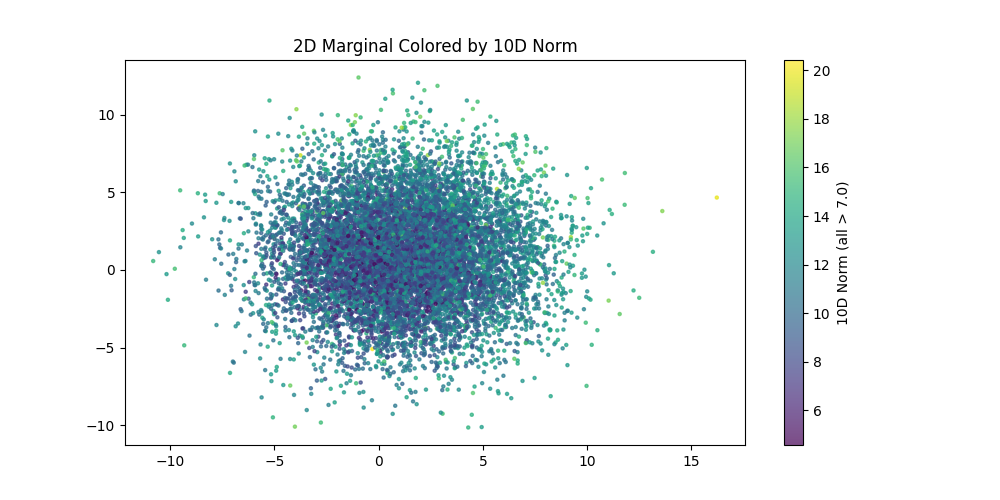

In [54]:
x_marg = S[:, :2].cpu()
norms_10d = S.norm(dim=1).cpu()

fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(111)
fig1 = ax1.scatter(x_marg[:, 0], x_marg[:, 1], c=norms_10d, s=5, alpha=0.7)
plt.colorbar(fig1, ax=ax1, label='10D Norm (all > 7.0)')
ax1.set_title('2D Marginal Colored by 10D Norm')
plt.show()

In [4]:
from delphi import oracle

dims = 1

true_mu, true_var = ch.zeros(dims), ch.eye(dims)
M = MultivariateNormal(true_mu, true_var) 
print(f'ground truth loc: {true_mu}')
print(f'ground truth var: {true_var}')
samples = M.rsample([5000,])
print(f'num total samples: {samples.size(0)}')
# generate ground-truth data
phi = oracle.Right_Distribution(ch.Tensor([0.0]))
# truncate
indices = phi(samples).nonzero()[:,0]
S = samples[indices]
print(f'num truncated samples: {S.size(0)}')
alpha = S.size(0) / samples.size(0)
emp_loc = S.mean(0)
emp_var = S.var(0)
print(f"emp loc: {emp_loc}")
print(f'emp var: {emp_var}')

ground truth loc: tensor([0.])
ground truth var: tensor([[1.]])
num total samples: 5000
num truncated samples: 2457
emp loc: tensor([-0.8046])
emp var: tensor([0.3707])


In [5]:
from delphi.distributions import UnknownTruncationNormal
from delphi.utils.helpers import Parameters

S_std_norm = (S - emp_loc) 
k = 3

# train algorithm
args = Parameters({
                    'epochs': 20, 
                    'batch_size': 10, 
                    'trials': 1, 
                    'verbose': True,
                    'lr': 1e-1,
                    'early_stopping': True,
                }) 
truncated = UnknownTruncationNormal(args,
                                    k,
                                    alpha,
                                    dims,
                                    covariance_matrix=ch.eye(1))
truncated.fit(S)

rescale_loc = truncated.best_loc_
print(f"pred loc: {rescale_loc}")
rescale_var = truncated.best_covariance_matrix_
print(f"pred var: {rescale_var}")

args: {'amsgrad': False,
 'batch_size': 10,
 'beta1': 0.9,
 'beta2': 0.999,
 'capturable': False,
 'constant': False,
 'covariance_matrix_lr': 0.01,
 'dampening': 0.0,
 'damping': 0.001,
 'device': 'cpu',
 'differentiable': False,
 'distribution': True,
 'early_stopping': True,
 'epochs': 20,
 'eps': 1e-05,
 'gamma': 0.1,
 'hessian_approx': 'auto',
 'lr': 0.1,
 'max_update_norm': 1.0,
 'maximize': False,
 'milestones': [30, 60, 90],
 'min_lr': 0.0,
 'momentum': 0.0,
 'nesterov': False,
 'num_samples': 10000,
 'optimizer': 'sgd',
 'plateau_cooldown': 0,
 'plateau_eps': 1e-08,
 'plateau_factor': 0.1,
 'plateau_mode': 'min',
 'plateau_patience': 10,
 'plateau_threshold': 0.0001,
 'plateau_threshold_mode': 'rel',
 'r': 1.0,
 'rate': 1.5,
 'step_lr': 100,
 'step_lr_gamma': 0.9,
 'tol': 0.1,
 'train_mode': 'step',
 'trials': 1,
 'val': 0.2,
 'verbose': True,
 'weight_decay': 0.0,
 'workers': 0}
trial: 1
Creating SGD optimizer: {'lr': 0.1, 'momentum': 0.0, 'dampening': 0.0, 'weight_decay': 0.

ipdb> batch[1][:,0][...,None]
tensor([[-0.1745],
        [-0.1684],
        [-2.6244],
        [-1.7667],
        [-1.9945],
        [-1.7777],
        [-0.2871],
        [-1.2947],
        [-1.1266],
        [-0.7194]])
ipdb> self.exp_h(self.v, self.T, batch[1][:,0][...,None])
tensor([[ 3.0232,  3.0282,  1.5466,  1.9556,  1.8375,  1.9497,  2.9315,  2.2251,
          2.3299,  2.6045],
        [ 3.0200,  3.0250,  1.5449,  1.9536,  1.8355,  1.9477,  2.9285,  2.2228,
          2.3275,  2.6018],
        [93.2105, 93.3656, 47.6835, 60.2952, 56.6526, 60.1133, 90.3843, 68.6057,
         71.8348, 80.3019],
        [14.1780, 14.2015,  7.2530,  9.1713,  8.6172,  9.1436, 13.7481, 10.4354,
         10.9266, 12.2145],
        [21.7588, 21.7950, 11.1311, 14.0751, 13.2248, 14.0327, 21.0990, 16.0151,
         16.7689, 18.7454],
        [14.4582, 14.4822,  7.3963,  9.3526,  8.7875,  9.3244, 14.0198, 10.6416,
         11.1425, 12.4559],
        [ 3.1027,  3.1079,  1.5873,  2.0071,  1.8858,  2.0010,  3.0

In [21]:
from delphi import oracle
dims = 1
# generate ground-truth data
M = MultivariateNormal(ch.zeros(dims), ch.eye(dims)) 
samples = M.rsample([10000,])
phi = oracle.Right_Distribution(ch.Tensor([0.0]))
indices = phi(samples).nonzero()[:,0]
S = samples[indices]
alpha = S.size(0) / samples.size(0)

print(f'alpha: {alpha}')
print(f'num total samples: {samples.size(0)}')
print(f'num truncated samples: {S.size(0)}')
emp_loc = S.mean(0)
emp_var = S.var(0)

print(f'emp loc: {emp_loc}')
print(f'emp var: {emp_var}')
print(f'known variance: {M.covariance_matrix}')
k = 3
print(f'k: {k}')

S_norm = S - emp_loc

# train algorithm
args = Parameters({
                    'epochs': 2, 
                    'trials': 1,
                    'batch_size': 1000,
                    'lr': 1e-1, 
                    'early_stopping': True,
                    'verbose': True,
                    'step_lr_gamma': 1.0,
                }) 
truncated = UnknownTruncationNormal(args, 
                                    k, 
                                    alpha, 
                                    dims, 
                                    covariance_matrix=M.covariance_matrix)
truncated.fit(S)

alpha: 0.5007
num total samples: 10000
num truncated samples: 5007
emp loc: tensor([-0.7983])
emp var: tensor([0.3605])
known variance: tensor([[1.]])
k: 3
args: {'amsgrad': False,
 'batch_size': 1000,
 'beta1': 0.9,
 'beta2': 0.999,
 'capturable': False,
 'constant': False,
 'covariance_matrix_lr': 0.01,
 'dampening': 0.0,
 'damping': 0.001,
 'device': 'cpu',
 'differentiable': False,
 'distribution': True,
 'early_stopping': True,
 'epochs': 2,
 'eps': 1e-05,
 'gamma': 0.1,
 'hessian_approx': 'auto',
 'lr': 0.1,
 'max_update_norm': 1.0,
 'maximize': False,
 'milestones': [30, 60, 90],
 'min_lr': 0.0,
 'momentum': 0.0,
 'nesterov': False,
 'num_samples': 10000,
 'optimizer': 'sgd',
 'plateau_cooldown': 0,
 'plateau_eps': 1e-08,
 'plateau_factor': 0.1,
 'plateau_mode': 'min',
 'plateau_patience': 10,
 'plateau_threshold': 0.0001,
 'plateau_threshold_mode': 'rel',
 'r': 1.0,
 'rate': 1.5,
 'step_lr': 100,
 'step_lr_gamma': 1.0,
 'tol': 0.1,
 'train_mode': 'step',
 'trials': 1,
 'val': 0

UnknownTruncationNormal()

In [22]:
dims = 1
std_normal = MultivariateNormal(ch.zeros(dims), ch.eye(dims))
emp_loc, emp_var = S.mean(0), S.var(0, keepdim=True)

pdf = ch.exp(std_normal.log_prob(S))[...,None]
loc_grad =  emp_loc - S
cov_grad = .5 * (ch.bmm(S.unsqueeze(2), S.unsqueeze(1)) - emp_var - emp_loc[...,None] @ emp_loc[None,...]).flatten(1)
data = ch.cat([S, pdf, loc_grad, cov_grad], dim=1)

k = 3
emp_loc, emp_var = S.mean(0), S.var(0, keepdim=True)
unknown_gaussian_oracle = UnknownGaussian(emp_loc[...,None], ch.eye(dims), S, k)
exp_h = Exp_h(emp_loc, ch.eye(dims))

In [23]:
ch.randperm(data.size(0))[:10]

tensor([1850, 3201, 4812, 2297, 1489, 4463, 4862, 2227, 3140, 3457])

In [24]:
mus = ch.linspace(-1, 2, 10)
losses = [unknown_trunc_nll(unknown_gaussian_oracle, exp_h, ch.tensor([m])[None,...], ch.eye(1), truncated.val_loader_.dataset.data)[0].item() for m in mus]

<IPython.core.display.Javascript object>


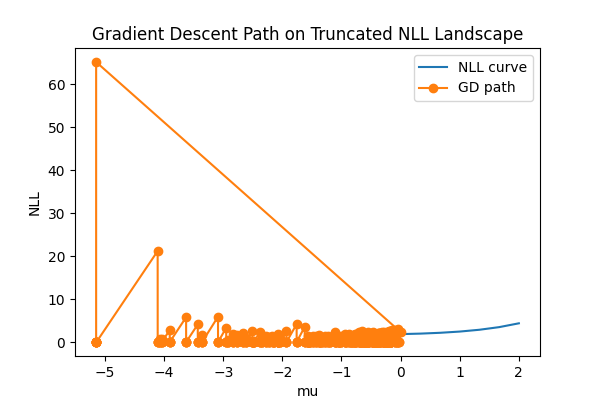

In [25]:
mu_history = truncated.trainer.param_history[:,1].detach()
loss_history = truncated.trainer.loss_history.detach()

plt.figure(figsize=(6,4))
plt.plot(mus, losses, label="NLL curve")
plt.plot(mu_history, loss_history, marker="o", label="GD path")
plt.xlabel("mu")
plt.ylabel("NLL")
plt.title("Gradient Descent Path on Truncated NLL Landscape")
plt.legend()
plt.show()

In [108]:
truncated.val_loader_.dataset.data

tensor([[-1.6164,  0.2721,  0.8059,  0.7939],
        [-0.5317,  0.5917, -0.2788, -0.3711],
        [-2.3500,  0.0263,  1.5395,  2.2487],
        ...,
        [-0.6345,  0.6305, -0.1760, -0.3112],
        [-0.1239,  0.3466, -0.6866, -0.5048],
        [-1.7603,  0.1930,  0.9498,  1.0369]])

In [26]:
truncated.trainer.param_history

tensor([[ 1.0000, -0.7950],
        [ 1.0000, -0.7948],
        [ 1.0000, -0.7947],
        [ 1.0000, -0.7946],
        [ 1.0000, -0.7484],
        [ 1.0000, -0.7483],
        [ 1.0000, -0.7481],
        [ 1.0000, -0.7480],
        [ 1.0000, -0.7479],
        [ 1.0000, -0.6490],
        [ 1.0000, -0.6488],
        [ 1.0000, -0.6487],
        [ 1.0000, -0.6486],
        [ 1.0000, -0.6484],
        [ 1.0000, -0.6268],
        [ 1.0000, -0.6266],
        [ 1.0000, -0.6264],
        [ 1.0000, -0.6263],
        [ 1.0000, -0.6262],
        [ 1.0000, -0.5974],
        [ 1.0000, -0.5974],
        [ 1.0000, -0.5972],
        [ 1.0000, -0.5971],
        [ 1.0000, -0.5969],
        [ 1.0000, -0.5876],
        [ 1.0000, -0.5875],
        [ 1.0000, -0.5873],
        [ 1.0000, -0.5872],
        [ 1.0000, -0.5871],
        [ 1.0000, -0.5456],
        [ 1.0000, -0.5455],
        [ 1.0000, -0.5454],
        [ 1.0000, -0.5452],
        [ 1.0000, -0.5450],
        [ 1.0000, -0.5393],
        [ 1.0000, -0

In [31]:
mu_history[loss_history.argmax() - 1]

tensor(0.0065)

In [68]:
S_std_norm = (S - emp_loc) / (emp_var ** .5)
phi_std_norm = oracle.Left_Distribution((phi.left - emp_loc).flatten() / (emp_var ** .5))


# train algorithm
args = Parameters({
                    'epochs': 10, 
                    'batch_size': 50, 
                    'trials': 1, 
                    'verbose': True,
                    'lr': 1e-1,
#                     'step_lr_gamma': 1.0,
                    'num_samples': 10000,
#                     'optimizer': 'adam'
                }) 
truncated = TruncatedNormal(args,
                              phi_std_norm, 
                              alpha, 
                              dims)
truncated.fit(S_std_norm)

rescale_loc = truncated.best_loc_ * (emp_var ** .5) + emp_loc
print(f"pred loc: {rescale_loc}")
rescale_var = truncated.best_variance_ * emp_var
print(f"pred var: {rescale_var}")

args: {'amsgrad': False,
 'batch_size': 50,
 'beta1': 0.9,
 'beta2': 0.999,
 'capturable': False,
 'constant': False,
 'dampening': 0.0,
 'damping': 0.001,
 'device': 'cpu',
 'differentiable': False,
 'distribution': True,
 'epochs': 10,
 'eps': 1e-05,
 'gamma': 0.1,
 'hessian_approx': 'auto',
 'lr': 0.1,
 'max_update_norm': 1.0,
 'maximize': False,
 'milestones': [30, 60, 90],
 'min_lr': 0.0,
 'momentum': 0.0,
 'nesterov': False,
 'num_samples': 10000,
 'optimizer': 'sgd',
 'plateau_cooldown': 0,
 'plateau_eps': 1e-08,
 'plateau_factor': 0.1,
 'plateau_mode': 'min',
 'plateau_patience': 10,
 'plateau_threshold': 0.0001,
 'plateau_threshold_mode': 'rel',
 'r': 1.0,
 'rate': 1.5,
 'stats': True,
 'step_lr': 100,
 'step_lr_gamma': 0.9,
 'tol': 0.1,
 'trials': 1,
 'val': 0.2,
 'verbose': True,
 'weight_decay': 0.0,
 'workers': 0}
trial: 1
Creating SGD optimizer: {'lr': 0.1, 'momentum': 0.0, 'dampening': 0.0, 'weight_decay': 0.0, 'nesterov': False, 'maximize': False, 'differentiable': Fals

In [69]:
truncated.final_loc_ * (emp_var ** .5) + emp_loc, truncated.final_covariance_matrix_* emp_var

(tensor([[-0.1989]]), tensor([[1.2636]]))

In [70]:
truncated.best_loc_ * (emp_var ** .5) + emp_loc, truncated.best_variance_ * emp_var

(tensor([[0.0051]]), tensor([[0.9816]]))

Ground truth: μ=0.000, σ=1.000
Minimum found: μ=0.053, σ=0.974, loss=0.748

Loss at ground truth: 0.750
Loss at minimum: 0.748
Difference: 0.001


<IPython.core.display.Javascript object>


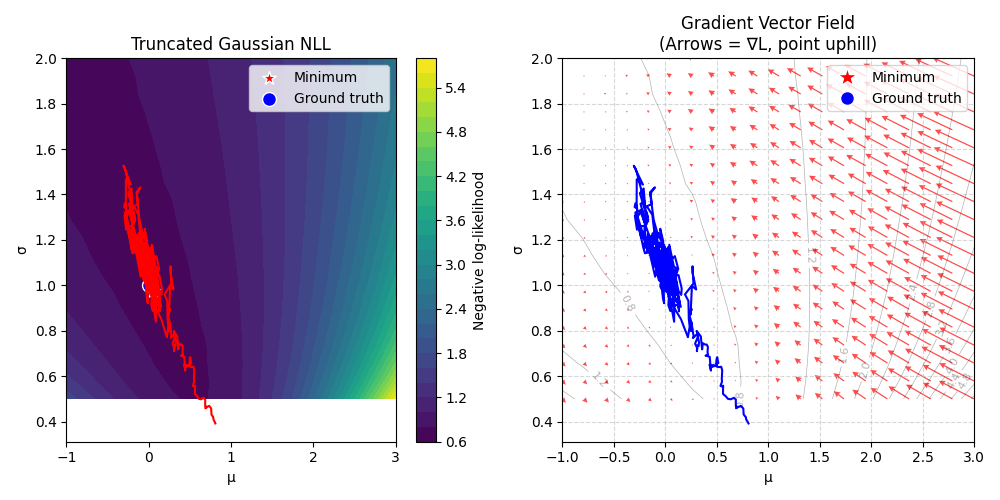

In [71]:
# === Parameter grids ===
mu_values = ch.linspace(-1.0, 3.0, 20)
sigma_values = ch.linspace(0.5, 2.0, 20)
MU, SIGMA = ch.meshgrid(mu_values, sigma_values)

# DATA 
trunc_multi_norm_score = TruncatedMultivariateNormalScore(known_cov=False)
sampler = PreSampler(dims, )
S_grad = trunc_multi_norm_score(S)
data = ch.cat([S, S_grad], dim=1)

# === Compute NLL over the grid ===
Z = np.zeros_like(MU)
MU_GRAD = np.zeros_like(MU)
SIGMA_GRAD = ch.zeros_like(SIGMA) 
for i in range(len(sigma_values)):
    for j in range(len(mu_values)):
        var = ch.Tensor([[SIGMA[i, j]]])
        loc = MU[i, j][...,None]
        loss, T_grad, v_grad = trunc_nll(phi, loc, var, data, known_cov=False, sampler=sampler)
        Z[i, j] = loss
        MU_GRAD[i, j] = T_grad.item()
        SIGMA_GRAD[i, j] = v_grad.item()
        
# Find the minimum point
min_idx = np.unravel_index(np.argmin(Z), Z.shape)
min_mu = MU[min_idx]
min_sigma = SIGMA[min_idx]
min_loss = Z[min_idx]

# === Analysis ===
print(f"Ground truth: μ={true_mu.item():.3f}, σ={true_var.sqrt().item():.3f}")
print(f"Minimum found: μ={min_mu:.3f}, σ={min_sigma:.3f}, loss={min_loss:.3f}")
print(f"\nLoss at ground truth: {trunc_nll(phi, true_mu, true_var, data)[0]:.3f}")
print(f"Loss at minimum: {min_loss:.3f}")
print(f"Difference: {trunc_nll(phi, true_mu, true_var, data)[0] - min_loss:.3f}")        
        
fig = plt.figure(figsize=(10, 5))

# Plot 1: 3D surface plot
ax1 = fig.add_subplot(121)
cp = ax1.contourf(MU, SIGMA, Z, levels=30, cmap="viridis")
plt.colorbar(cp, ax=ax1, label="Negative log-likelihood")
# surf = ax1.plot_surface(MU, SIGMA, Z, cmap='viridis', alpha=0.8, 
#                        linewidth=0, antialiased=True)
ax1.scatter([min_mu], [min_sigma], color='red', s=100, 
           label='Minimum', marker='*', edgecolors='white')
ax1.scatter([true_mu.item()], [true_var.sqrt().item()], 
           color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')
ax1.set_title("Truncated Gaussian NLL")
ax1.set_xlabel("μ")
ax1.set_ylabel("σ")
ax1.legend()
ax1.legend()

param_history = truncated.trainer.param_history 

T = param_history[:,0]
v = param_history[:,1]

SIGMA_ = (1/T[...,None])
MU_ = SIGMA_ * v[...,None]

SIGMA_ = SIGMA_ * emp_var
MU_ = MU_ * (emp_var ** .5) + emp_loc

ax1.plot(MU_.detach(), SIGMA_.detach(), color='red')

ax2 = fig.add_subplot(122)

# Plot quiver
Q = ax2.quiver(MU, SIGMA, MU_GRAD, SIGMA_GRAD,
               color='red', alpha=0.7, width=0.003, scale=50, headwidth=5)

# Add contour of loss for context
contour = ax2.contour(MU, SIGMA, Z, levels=15, colors='black', alpha=0.3, linewidths=0.5)
ax2.clabel(contour, inline=True, fontsize=8, fmt="%.1f")

# Mark minimum and ground truth
ax2.plot(min_mu, min_sigma, 'r*', markersize=15, markeredgecolor='white', label='Minimum')
ax2.plot(true_mu.item(), true_var.sqrt().item(), 'bo', markersize=10, markeredgecolor='white', label='Ground truth')

ax2.set_xlabel('μ')
ax2.set_ylabel('σ')
ax2.set_title('Gradient Vector Field\n(Arrows = ∇L, point uphill)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

ax2.plot(MU_.detach(), SIGMA_.detach(), color='blue')


plt.tight_layout()
plt.show()

In [72]:
truncated.optimizer

SGD (
Parameter Group 0
    dampening: 0.0
    differentiable: False
    foreach: None
    fused: None
    initial_lr: 0.1
    lr: 0.06561000000000002
    maximize: False
    momentum: 0.0
    nesterov: False
    weight_decay: 0.0
)

In [73]:
param_history = truncated.trainer.param_history 


T = param_history[:,0]
v = param_history[:,1]
SIGMA = (1/T[...,None])
MU = SIGMA * v[...,None]

SIGMA = SIGMA * emp_var
MU = MU * (emp_var ** .5) + emp_loc

In [161]:
loss_history = truncated.trainer.loss_history
ch.argmin(loss_history)

tensor(171)

In [202]:
truncated.optimizer

SGD (
Parameter Group 0
    dampening: 0.0
    differentiable: False
    foreach: None
    fused: None
    initial_lr: 0.1
    lr: 0.1
    maximize: False
    momentum: 0.0
    nesterov: False
    weight_decay: 0.0
)

In [201]:
argmin = ch.argmin(ch.abs(0 - MU_))
MU_[argmin], SIGMA_[argmin]

(tensor([-0.0043]), tensor([0.9805]))

In [163]:
best_params = param_history[461]

best_var, best_mu = best_params[0], best_params[1]

best_sigma = 1/best_var

best_loc = best_sigma*best_mu

best_sigma * emp_var, best_loc * (emp_var ** .5) + emp_loc

(tensor([0.8831]), tensor([0.1193]))

<IPython.core.display.Javascript object>


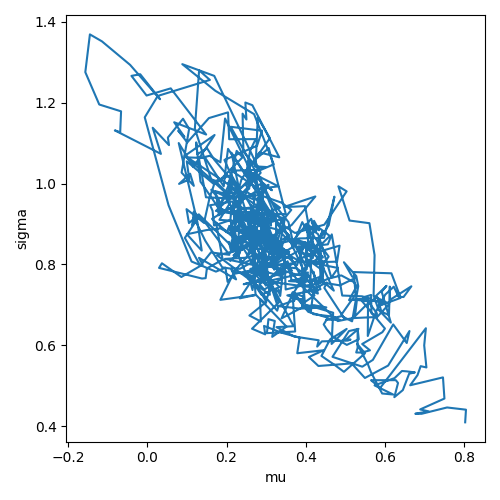

In [88]:
param_history, loss_history = truncated.trainer.param_history, truncated.trainer.loss_history


fig = plt.figure(figsize=(5, 5))

# Plot 1: 3D surface plot
ax1 = fig.add_subplot(111)
# surf = ax1.plot_surface(MU, SIGMA, Z, cmap='viridis', alpha=0.8, 
#                        linewidth=0, antialiased=True)
# ax1.scatter([min_mu], [min_sigma], [min_loss], color='red', s=100, 
#            label='Minimum', marker='*', edgecolors='white')
# ax1.scatter([true_mu.item()], [true_var.sqrt().item()], [np.min(Z)], 
#            color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')
# ax1.set_xlabel('μ')
# ax1.set_ylabel('σ')
# ax1.set_zlabel('Negative Log-Likelihood')
# ax1.set_title('3D Loss Landscape')
# ax1.legend()

ax1.plot(MU, SIGMA)
ax1.set_xlabel('mu')
ax1.set_ylabel('sigma')


plt.tight_layout()
plt.show()

In [90]:
MU

tensor([0.3301])

In [85]:
emp_loc

tensor([0.8317])

In [ ]:
# Vary mu[0] and sigma[0], fix others
mu0_vals = ch.linspace(true_mu[0] - 2, true_mu[0] + 2, 30)
sigma0_vals = ch.linspace(0.5, 2.0, 30)
MU0, SIGMA0 = ch.meshgrid(mu0_vals, sigma0_vals)

Z = np.zeros((len(sigma0_vals), len(mu0_vals)))
GRAD_MU0 = np.zeros_like(Z)
GRAD_SIGMA0 = np.zeros_like(Z)

for i in range(len(sigma0_vals)):
    for j in range(len(mu0_vals)):
        # Build full mu and Sigma
        mu = true_mu.clone()
        mu[0] = MU0[i, j]
        
        sigma = true_sigma.clone()
        sigma[0] = SIGMA0[i, j]
        Sigma = ch.diag(sigma ** 2)
        
        loss, grad = trunc_nll(mu, Sigma, data, known_cov=False)
        Z[i, j] = loss
        
        # Extract ∂L/∂μ₀ and ∂L/∂σ₀
        dL_dv0 = grad[dims*dims + 0]           # ∂L/∂v₀
        dL_dT00 = grad[0]                      # ∂L/∂T₀₀ (since T is diagonal, T₀₀ is first)
        
        T00 = 1.0 / (sigma[0] ** 2)
        dL_dmu0 = dL_dv0 * T00
        dL_dsigma0 = dL_dT00 * (-2.0 / (sigma[0] ** 3))
        
        GRAD_MU0[i, j] = dL_dmu0
        GRAD_SIGMA0[i, j] = dL_dsigma0